# МНАД ФКН ВШЭ
# Семинар 2
# Linear, Dropout, BN

Перед тем, как начать семинар, давайте вкратце обсудим, на каких устройствах и почему мы считаем наши вычисления нейронных сетей.




1. **GPU** (графические процессоры) — основная рабочая лошадка современного машинного обучения. GPU содержат тысячи простых ядер, идеально подходящих для параллельных матричных операций, составляющих основу нейросетевых вычислений. Важно выделить два главных конкурента на рынке:

    1.1. **CUDA** NVIDIA доминирует в этой сфере с линейкой A100, H100, RTX 4090. Архитектуры Hopper и Ada Lovelace обеспечивают до 989 TOPS для ИИ-вычислений. Платформа CUDA имеет зрелую экосистему библиотек (cuDNN, cuBLAS), широкую поддержку фреймворков и оптимизированные драйверы, что делает NVIDIA стандартом индустрии (90% всех вычислений на видеокарточках NVIDIA) [1](https://developer.nvidia.com/cuda-toolkit), [2](https://github.com/NVIDIA/CUDALibrarySamples), [3](https://en.wikipedia.org/wiki/CUDA).

    1.2. **ROCm** AMD предлагает открытую альтернативу CUDA с картами MI300X, RX 7900 XTX. Поддерживает PyTorch, TensorFlow и JAX через HIP API. Преимущества: открытый исходный код, конкурентная цена, поддержка Linux. Но пока что меньшая экосистема библиотек, ограниченная совместимость с некоторыми фреймворками, много багов [1](https://www.amd.com/en/products/software/rocm.html), [2](https://github.com/ROCm/ROCm), [3](https://en.wikipedia.org/wiki/ROCm).

2. **TPU** от Google — тензорные процессоры, специально разработанные для нейросетевых вычислений. TPU v5 обеспечивает до 459 TOPS при энергопотреблении 200W. Оптимизированы для матричных операций, поддерживают bfloat16, интегрированы с TensorFlow/JAX. Доступны только через Google Cloud/Colab и работают в полную силу только на JAX [1](https://en.wikipedia.org/wiki/Tensor_Processing_Unit), [2](https://cloud.google.com/tpu).

3. **NPU** Huawei Ascend — китайская альтернатива западным решениям (+5 социального рейтинга от партии). Ascend 910B предлагает до 256 TOPS FP16, поддерживает MindSpore фреймворк. Особенности: собственная архитектура Da Vinci, оптимизация для китайского рынка, интеграция с облачными сервисами Huawei Cloud. Минусы такие же, как и у ROCm **AMD** [1](https://www.hiascend.com/en/), [2](https://gitee.com/ascend/pytorch).

4. **Metal** чипы от Apple (M-серия) — интегрированные процессоры с унифицированной памятью. Преимущества: энергоэффективность, бесшовная интеграция с macOS, оптимизированные Metal Performance Shaders. Поддержка CoreML, TensorFlow Lite. Ограничения: только экосистема Apple, возможно только что-то локальное запускать на инференс, обучать что-то серьезное не получится [1](https://developer.apple.com/metal/), [2](https://developer.apple.com/metal/pytorch/).
5. **CPU** используются для менее требовательных задач и вывода небольших моделей, но значительно медленнее GPU для обучения.

Почему считаем на видеокарточках? Нейросети требуют:

- Массовых параллельных вычислений (миллионы параметров обновляются одновременно).

- Интенсивных матричных операций (тензорные умножения, свертки).

- Оптимизированных операций с плавающей точкой.

Чтобы понять преимущество, посмотрите это [видео](https://www.youtube.com/watch?v=Ge-g3xZ5bb8).



Вы видели упоминание всяких FP16/BF16, операций с плавающией точкой и так далее, об этом поговорим чуть позже.

Давайте вкратце сначала обсудим про основные фреймворки в DL: `TensorFlow`, `JAX`, `Keras` и `Pytorch`.

## Фреймворки в DL

### TensorFlow


[TensorFlow](https://www.tensorflow.org) - один из самых известных фреймворков глубокого обучения, созданный Google Brain в 2015 году. Изначально он строился вокруг статических вычислительных графов, что позволяло эффективно оптимизировать и компилировать вычисления для масштабного обучения, особенно на GPU и TPU. Такая архитектура была мощной, но вызывала у исследователей затруднения: приходилось заранее описывать граф, что делало отладку и эксперименты менее гибкими.


С течением времени TensorFlow прошел эволюцию. Появилось Eager Execution (динамический режим, аналогичный PyTorch), а также множество надстроек, включая Keras как основной высокоуровневый API. TensorFlow развивается не только как библиотека для обучения моделей, но и как экосистема для продакшна. Здесь выделяются:

- TensorFlow Serving - система для развертывания и обслуживания моделей.

- TensorFlow Lite - инструментарий для оптимизации и запуска моделей на мобильных устройствах и микроконтроллерах.

- TensorFlow.js - запуск моделей прямо в браузере.

Главное преимущество, что есть поддержка TPU и сразу из коробки есть возможность развернуть на слабых устройствах.

TensorFlow постепенно уступил позиции PyTorch.

Основные причины: более сложный интерфейс в ранних версиях, медленное внедрение динамических графов и менее “питонический” стиль кода.

### JAX

[JAX](https://github.com/jax-ml/jax) - относительно новый инструмент от Google Research, который позиционируется не столько как полноценный фреймворк для нейросетей, сколько как библиотека для ускоренных численных вычислений и автоматического дифференцирования. По сути, JAX объединяет возможности NumPy, автоматического дифференцирования (autograd) и компиляции XLA, что делает его мощным инструментом для научных исследований.

Основные идеи JAX заключаются в нескольких ключевых трансформациях:

`grad` - автоматическое вычисление градиентов.

`jit` - Just-In-Time компиляция, позволяющая ускорить выполнение кода за счёт оптимизации и компиляции под XLA.

`vmap` - векторизация, позволяющая автоматически параллелить вычисления по батчам данных.

`pmap` - распределённое выполнение на множестве устройств (GPU/TPU).

Важно, что JAX по философии ближе к функциональному программированию: в отличие от PyTorch и TensorFlow, которые живут по объектно-ориентированные паттернам, JAX требует работы с чистыми функциями и трансформациями.

Поверх JAX развилась экосистема:

1. [Flax](https://github.com/google/flax) - гибкая библиотека для нейросетей.

2. [Haiku](https://github.com/google-deepmind/dm-haiku) (DeepMind) - более модульный подход.

3. [Optax](https://github.com/google-deepmind/optax) - набор оптимизаторов.

4. [RLax](https://github.com/google-deepmind/rlax) - компоненты для обучения с подкреплением.

Преимущество JAX - очень высокая производительность и гибкость. Его можно ценить за возможность быстро экспериментировать со сложной математикой (например, PDE-решатели или физически-информированные нейросети) и при этом масштабироваться на TPU-кластеры.

Недостаток JAX - это ещё относительно «молодая» экосистема. Нет такого количества готовых моделей и обучающих материалов, как у PyTorch. Кроме того, JAX требует более глубокого понимания программирования и функционального подхода, что повышает порог вхождения.

### Keras

[Keras](https://keras.io/) - это высокоуровневый API для глубокого обучения, изначально разработанный как независимая библиотека известным ученым [Франсуа Шолле](https://scholar.google.com/citations?user=VfYhf2wAAAAJ&hl=en), но позже интегрированный в TensorFlow. Сегодня Keras 3 (выпущенный в 2023 – 2024 годах) поддерживает мультибэкенд: работать можно не только с TensorFlow, но и с PyTorch и JAX.
По факту - это оболочка над 3-я фреймворками.

Главная идея Keras - простота и читаемость [!важно]. Даже на главной странице написано:

> *Keras is a deep learning API designed for human beings, not machines.*



В то время как TensorFlow и PyTorch требуют описывать детали графа или слоя, Keras предоставляет декларативный и понятный стиль:` model = Sequential([Dense(...), Activation(...)])`.

Но естественно простота несет за собой более ограниченный контроль по сравнению с «чистыми» фреймворками. И из-за этого практически нигде не используется, кроме как фреймворк для обучения работы с DL.

### PyTorch

[PyTorch](https://pytorch.org/) появился в 2017 году в FAIR как «питоничный» наследник Torch7 (Lua). Он сделал ставку на динамические вычислительные графы и автодифференцирование, что резко упростило исследовательскую работу. Благодаря простоте, гибкости и тесной интеграции с экосистемой Python он быстро стал стандартом в академии и индустрии, вытеснив статические графы эпохи TensorFlow 1.x.

Почему он крут и популярен:

- Удобство: естественный Python-API, простая отладка, контроль потока (if/for).
- Производительность: CUDA, AMP, `torch.compile` (2.x), профилировщик.
- Масштаб: DDP/FSDP, поддержка огромных моделей.
- Экосистема: torchvision/torchaudio/torchtext и стал основой для Hugging Face.
- Продакшн: TorchServe, ONNX/TensorRT, C++ libtorch.
- Сообщество: тысячи туториалов, быстрый выпуск фич, удобство интегрирования свое.

Ключевые преимущества: динамический граф + удобство Python → быстрые исследования и надёжный продакшн.

### Сравнительная таблица

| Фреймворк      | Основная идея             | Сильные стороны                                   | Слабые стороны                           | Основные сферы применения |
|----------------|---------------------------|--------------------------------------------------|------------------------------------------|---------------------------|
| **TensorFlow** | Статический/динамический граф | Продакшн-инструменты, поддержка TPU, кросс-платформенность | Сложнее для исследований, менее питоничный | Поддержание старых решений, мобильные/веб-решения |
| **JAX**        | Функциональный стиль, XLA, автодиф | Высокая производительность, гибкость, TPU-кластеризация | Молодая экосистема, высокий порог входа   | Cutting-edge исследования, математика, физика |
| **Keras**      | Высокоуровневый API        | Простота, мультибэкенд, быстрые прототипы        | Ограниченный контроль, меньше гибкости   | Обучение, быстрый старт, учебные курсы |
| **PyTorch**    | Динамический граф          | Простота, гибкость, огромное сообщество, продакшн-инструменты | Ранее слабый деплой, но за счет сообщества щас все норм | Промышленный деплой, исследования, индустрия, курсы |


## Torch

### Установка PyTorch

In [ ]:
# !pip install torch

См. [здесь](https://pytorch.org/get-started/locally/), как установить PyTorch с поддержкой GPU для различных операционных систем.



### Активируем GPU (если в колабе)

По шагам:

1. Нажимаем "Среда выполнения" (сверху на панели).
2. Нажимаем "Сменить среду выполнения".
3. Выбираем Графический процессор T4.

In [ ]:
!nvidia-smi

Sat Aug 23 14:16:30 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Проверяем, что все работает

In [ ]:
import torch

print("Версия torch:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Версия torch: 2.8.0+cu126
Устройство: cuda


### Вспомогательные функции

In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

torch.manual_seed(0)

### Типы данных (`dtype`)

Тип данных - это формальное описание того, какие значения может хранить переменная и какие операции над ней допустимы. Типы данных позволяют компьютеру корректно интерпретировать двоичное представление информации. Например, набор бит 01000001 может означать число 65 в десятичной системе, а может обозначать символ 'A' в кодировке ASCII.

Таким образом, `dtype` определяет:

1. Вид значения — целое, вещественное, булево и т.п.

2. Разрядность (8, 16, 32, 64 бит), которая влияет на диапазон возможных значений, точность и объём памяти.

PyTorch [поддерживает разные типы данных](https://docs.pytorch.org/docs/stable/tensors.html):

<!-- - **Целые числа:**  
  `torch.int8`, `torch.int16`, `torch.int32`, `torch.int64`

- **Вещественные числа:**  
  `torch.float16`, `torch.float32`, `torch.float64`

- **Булевы:**  
  `torch.bool`

- **Комплексные:**  
  `torch.complex64`, `torch.complex128`

**По умолчанию:**
- для целых — `torch.int64`
- для вещественных — `torch.float32` -->

| dtype                      | Диапазон значений                                  | Где применяется                                                         |
| -------------------------- | -------------------------------------------------- | ----------------------------------------------------------------------- |
| **torch.uint8**            | 0 … 255                                            | Маски, изображения в формате byte (0–255 пиксели)                       |
| **torch.int8**             | –128 … 127                                         | Квантованные модели, экономия памяти                                    |
| **torch.int16**            | –32 768 … 32 767                                   | Редко используется, промежуточный тип                                   |
| **torch.int32**            | –2 147 483 648 … 2 147 483 647                     | Индексы, работа с табличными данными                                    |
| **torch.int64**            | –9.22e18 … 9.22e18                                 | Индексы тензоров, метки классов (стандарт в PyTorch)                    |
| **torch.float16 (Half)**   | \~ ±6.5e4, точность \~3 знака                      | Обучение на GPU (Mixed Precision), ускорение вычислений                 |
| **torch.bfloat16**         | \~ ±3.4e38, точность \~3 знака (короткая мантисса) | Обучение на современных GPU/TPU, баланс между скоростью и стабильностью |
| **torch.float32 (Float)**  | \~ ±3.4e38, точность \~7 знаков                    | Основной тип для обучения нейросетей (default)                          |
| **torch.float64 (Double)** | \~ ±1.8e308, точность \~15 знаков                  | Научные вычисления, когда нужна высокая точность                        |
| **torch.bool**             | True / False                                       | Логические маски, фильтрация элементов                                  |
| **torch.complex64**        | Два float32 (вещественная + мнимая часть)          | Сигнальная обработка, квантовая физика                                  |
| **torch.complex128**       | Два float64                                        | Высокоточные комплексные вычисления                                     |

---


![Чиселки](https://sungminlee0810.github.io/assets/images/2021_0224/image1.png)

Мы не всегда используем `float16`, потому что этот формат слишком ограничен по диапазону и точности, что часто делает обучение нейросетей нестабильным.  

- В реальных вычислениях (например, при экспоненте в softmax) встречаются гораздо большие числа. Это приводит к **переполнению (overflow)**, когда значения превращаются в `inf`, или наоборот - к **обнулению (underflow)** для очень маленьких чисел.  
- Градиенты в обучении часто бывают очень малыми $(10^{-6}$, $10^{-8})$, и в `float16` они просто исчезают, становясь нулями.  

Поэтому `float16` применяют в основном в режиме **mixed precision** (смешанная точность): часть операций и веса в `float16`, но накопление градиентов и критические вычисления остаются в `float32`. Это позволяет использовать преимущества FP16 (меньше памяти и быстрее на GPU с Tensor Cores) без потери стабильности.  

---

Мы практически никогда не используем **float64** (double precision), потому что:  

- он требует **в 2 раза больше памяти**,  
- выполняется значительно медленнее на GPU (многие ускорители сильно ограничены по FP64-производительности),  
- в 99% задач машинного обучения такой точности просто не требуется.  
- [в 1% задач](https://arxiv.org/html/2505.10949v1).  

---

В итоге, **основной рабочий формат в нейросетях - `float32` (`FP32`)**.  

- `FP32` - это "золотой стандарт": именно в нём PyTorch по умолчанию создает тензоры и обучает модели.  Он обеспечивает баланс между скоростью, точностью и стабильностью.


> **Важно!**, чтобы все данные имели один и тот же тип, иначе это может привести к неожиданным ошибкам.

### Случайная инициализация

Давайте вспомним формулу линейного слоя:  

$$
y = Wx + b,
$$

где $W \in \mathbb{R}^{m \times n}$ - матрица весов.  
Именно её мы и инициализируем случайными числами.  

*Зачем это нужно?*

**1. Разрушить симметрию.**  
Если все веса задать одинаковыми (например, нулями), то все нейроны будут вычислять одно и то же, а их градиенты совпадут.  
Сеть станет «копией одного нейрона». Случайная инициализация ломает эту симметрию.  

**2. Сохранить масштаб сигналов.**  
Если веса слишком большие — выход $y$ «взорвётся», если слишком маленькие — сигнал затухнет.  
Хорошая инициализация подбирает диапазон случайных чисел так, чтобы значения оставались в рабочем масштабе.  

**3. Ускорить обучение.**  
Благодаря корректной инициализации оптимизация быстрее сходится, а сеть стабильнее обучается.  

#### Xavier и Kaiming

- **Xavier (Glorot) initialization**  
  Подбирает дисперсию весов так, чтобы средний масштаб входов и выходов совпадал.  
  Лучше всего работает с симметричными активациями вроде **tanh** или **sigmoid**.

- **Kaiming initialization**  
  Разработана специально для **ReLU**. Эта активация обнуляет отрицательные значения, уменьшая дисперсию сигнала.  
  Kaiming нормализует веса так, чтобы масштаб сохранялся и обучение не затухало.  

---

Итог: случайные веса - это не хаос, а продуманное начало, которое делает нейроны уникальными, сохраняет масштаб сигналов и ускоряет обучение.


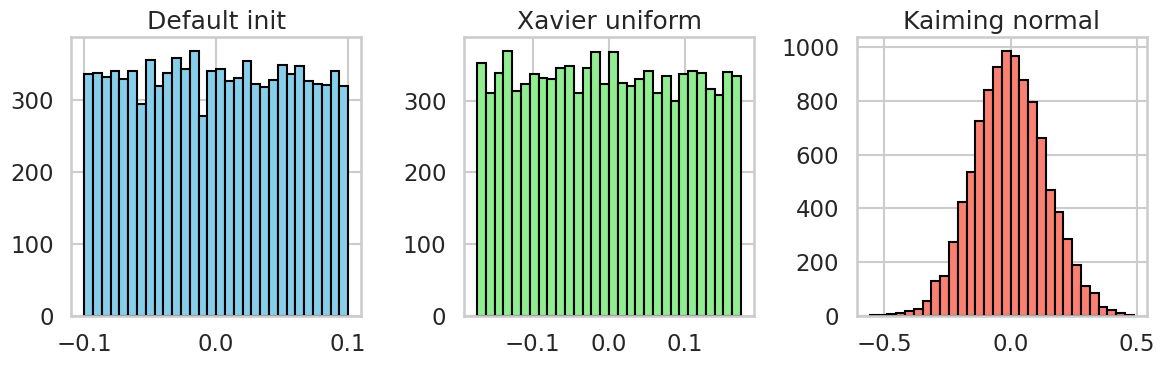

In [ ]:
layer = nn.Linear(100, 100, bias=False)

# 1. По умолчанию (uniform из [-1/sqrt(in), 1/sqrt(in)])
default_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

# 2. Xavier uniform
nn.init.xavier_uniform_(layer.weight)
xavier_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

# 3. Kaiming normal (под ReLU)
nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
kaiming_weights = layer.weight.detach().clone().view(-1).cpu().numpy()

# Визуализация
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(default_weights, bins=30, color="skyblue", edgecolor="black")
plt.title("Default init")

plt.subplot(1, 3, 2)
plt.hist(xavier_weights, bins=30, color="lightgreen", edgecolor="black")
plt.title("Xavier uniform")

plt.subplot(1, 3, 3)
plt.hist(kaiming_weights, bins=30, color="salmon", edgecolor="black")
plt.title("Kaiming normal")

plt.tight_layout()
plt.show()

### Слой `Dropout`:

Dropout - это метод регуляризации нейронных сетей, который помогает снизить риск переобучения.

Во время обучения Dropout случайным образом зануляет выходные активации части нейронов с вероятностью $p$, уменьшая их вклад в дальнейшие вычисления.

**Формула Dropout:**

$$
y = \frac{1}{1-p} \cdot (x \odot m), \quad m \sim \text{Bernoulli}(1-p)
$$

где:

- $x$ - вектор активаций,
- $m$ - бинарная маска (0 или 1),
- $\odot$ - поэлементное умножение.

Масштабирование на $\frac{1}{1-p}$ необходимо для того, чтобы сохранить математическое ожидание активаций:

$$
\mathbb{E}[y] = \mathbb{E}[x].
$$

Иначе средний уровень сигнала на каждом слое изменялся бы в зависимости от вероятности зануления, что мешало бы обучению.

Dropout препятствует тому, чтобы сеть чрезмерно полагалась на отдельные связи, и способствует формированию более устойчивых признаков.

На этапе инференса зануление не выполняется - сеть использует все активации, уже отмасштабированные при обучении.

Интуиция:

– В ходе обучения часть нейронов "не даёт сигнал дальше".

– Это вынуждает соседние нейроны не полагаться только на конкретные связи, а искать более устойчивые комбинации признаков.

– На этапе инференса (test) ни один нейрон не зануляется - используется полная сеть, но с масштабированными весами/активациями.

In [ ]:
layer = nn.Dropout(p=0.5)
print(layer(torch.tensor([[1, 1, 1, 1]], dtype=torch.float)))

# На собеседованиях часто спрашивают, как работает Dropout и дают именно этот пример

tensor([[2., 0., 0., 2.]])


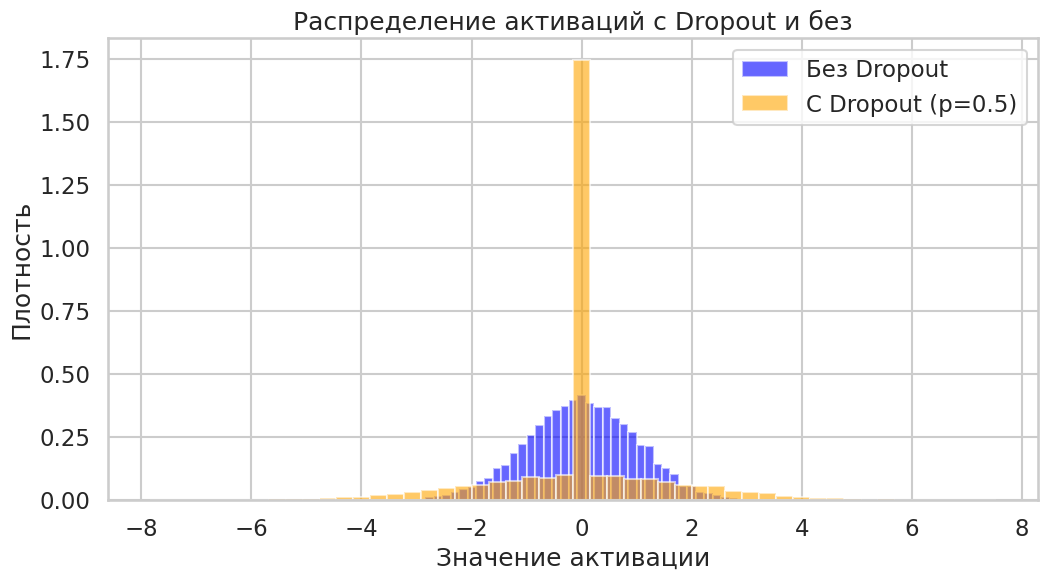

In [ ]:
# Генерируем случайные активации
x = torch.randn(10000)

# Dropout с p=0.5
dropout = nn.Dropout(p=0.5)
x_dropped = dropout(x)

# Перевод в numpy
x_np = x.detach().numpy()
x_dropped_np = x_dropped.detach().numpy()

# Построение графика
plt.figure(figsize=(12, 6))
plt.hist(x_np, bins=50, alpha=0.6, label="Без Dropout", density=True, color="blue")
plt.hist(
    x_dropped_np,
    bins=50,
    alpha=0.6,
    label="С Dropout (p=0.5)",
    density=True,
    color="orange",
)

plt.title("Распределение активаций с Dropout и без", fontsize=18)
plt.xlabel("Значение активации")
plt.ylabel("Плотность")
plt.legend()
plt.show()

## Cross-Entropy

### Бинарная классификация

Пойдем по определению [Бишопа](https://scholar.google.com/citations?user=gsr-K3ADUvAC&hl=en)

Рассмотрим бинарную классификацию с целевой переменной $t\in\{0,1\}$, где $t=1$ – класс $C_1$, а $t=0$  класс $C_2$.

Пусть нейросеть имеет один выход с логистической сигмоидой, так что $0\le y(\mathbf{x},\mathbf{w})\le 1$.

Интерпретируем $y(\mathbf{x},\mathbf{w})$ как $p(C_1\mid \mathbf{x})$, тогда $p(C_2\mid \mathbf{x})=1-y(\mathbf{x},\mathbf{w})$.

**Условное распределение Бернулли:**
$$
p(t\mid \mathbf{x},\mathbf{w})=y(\mathbf{x},\mathbf{w})^{\,t}\,[1-y(\mathbf{x},\mathbf{w})]^{\,1-t}.
$$

Для обучающего набора из независимых наблюдений функция ошибки – это negative log likelihood (кросс-энтропия):
$$
E(\mathbf{w})=-\sum_{n=1}^{N}\Big[t_n\ln y_n+(1-t_n)\ln(1-y_n)\Big],
$$
где $y_n \equiv y(\mathbf{x}_n,\mathbf{w})$.

> На практике использование кросс-энтропии вместо суммы квадратов часто ускоряет обучение и улучшает обобщение (Simard, Steinkraus, Platt, 2003).

Давайте просуммируем все ранее

Кросс-энтропия — это **честная шкала качества** для вероятностей модели.

**Логика:**
- Модель не говорит просто «0/1», она даёт **вероятность** правильного класса
- Если на верный класс ставишь высокую вероятность — хорошо; если **уверенно не туда**, то штрафуем сильно
- **Штраф для одного примера:**
  $$
  -\big[t\log y + (1-t)\log(1-y)\big].
  $$
  Здесь $y$ – предсказанная вероятность «класс = 1», а $t\in\{0,1\}$ – истинный лейбл.

**Обучение:**
- Суммируем по датасету и **минимизируем**:
  $$
  E(\mathbf{w}) \;=\; -\sum_{n=1}^{N}\Big[t_n\log y_n + (1-t_n)\log(1-y_n)\Big],
  $$
  где $y_n = y(\mathbf{x}_n,\mathbf{w})$.

Давайте напишем код кросс-энтропии

In [ ]:
def binary_cross_entropy(y_pred, y_true, epsilon=1e-7):
    """

    E = -1/N * Σ[t*ln(y) + (1-t)*ln(1-y)], t – это y_true
    """

    # Защита от log(0)
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)  ### Your CODE:

    # Формула Бишопа
    loss = -(
        y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)
    )  ### Your CODE:

    return loss.mean()

In [ ]:
z = torch.tensor([[-1.0, 0.2, 2.5], [0.0, -4.0, 1.0]])
p = torch.sigmoid(z)
y = torch.tensor([[0.0, 1.0, 1.0], [0.0, 0.0, 1.0]])

loss_ours = binary_cross_entropy(p, y)
loss_ref = F.binary_cross_entropy(p, y, reduction="mean")

In [ ]:
print("loss_ours", loss_ours)
print("loss_ref", loss_ref)

loss_ours tensor(0.3358)
loss_ref tensor(0.3358)




### Независимые бинарные задачи (K выходов)

Если нужно провести $K$ **отдельных** бинарных классификаций, то используем нейросеть с $K$ выходами, каждый с сигмоидой.  
Пусть лейбл класса $k$: $t_k\in\{0,1\}$, $k=1,\dots,K$.  
При предположении независимости меток условное распределение:
$$
p(\mathbf{t}\mid \mathbf{x},\mathbf{w})
=\prod_{k=1}^{K} y_k(\mathbf{x},\mathbf{w})^{\,t_k}\,[1-y_k(\mathbf{x},\mathbf{w})]^{\,1-t_k}.
$$

**Отрицательное лог-правдоподобие (кросс-энтропия):**
$$
E(\mathbf{w})
=-\sum_{n=1}^{N}\sum_{k=1}^{K}
\Big[t_{nk}\ln y_{nk}+(1-t_{nk})\ln(1-y_{nk})\Big],
$$
где $y_{nk}\equiv y_k(\mathbf{x}_n,\mathbf{w})$.

> Производные этой функции ошибки по предварительным активациям конкретного выхода имеют стандартный вид (как в случае регрессии): градиент пропорционален $y - t$, что обеспечивает простой и стабильный сигнал обучения.


## Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift

Так называется оригинальная [статья](https://arxiv.org/abs/1502.03167), с чего все началось.

**Batch Normalization (BatchNorm)** – это один из ключевых методов стабилизации и ускорения обучения нейронных сетей. **BatchNorm** нужен для борьбы с проблемой *внутреннего ковариационного сдвига* (internal covariate shift), когда распределение входов в каждый слой сети сильно меняется по мере обновления весов, что замедляет обучение.  

Если говорить по-простому, когда мы обучаем нейросеть, у неё на каждом слое появляются какие-то "промежуточные данные" – активации. Проблема в том, что эти данные постоянно "плывут": после каждой итерации обучения распределение значений на входе слоя меняется, потому что обновились веса предыдущих слоёв. Это и называют внутренним ковариационным сдвигом.

### Формулки

Пусть у нас есть входные данные $x_1, x_2, \dots, x_m$ в батче размером $m$.  
Процесс нормализации выглядит так:  

1. Считаем среднее по батчу:

    $$
    \mu_B = \frac{1}{m} \sum_{i=1}^m x_i
    $$

2. Считаем дисперсию (разброс значений):

    $$
    \sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
    $$

3. Нормализуем каждое значение (приводим к нулевому среднему и единичной дисперсии):

    $$
    \hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
    $$

где $\epsilon$ — очень маленькая константа, которая нужна для численной стабильности (чтобы не делить на ноль).

4. Добавляем обучаемые параметры (масштаб $\gamma$ и сдвиг $\beta$):

    $$
    y_i = \gamma \hat{x}_i + \beta
    $$


> P.S. Очень любят спрашивать на собеседованиях.

### Как работает BatchNorm в `train()` и `eval()` в PyTorch

**В режиме `model.train()`**
- Нормируем **по статистикам текущего мини-батча**:
  
  $
  y = \gamma \cdot \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}} + \beta
  $

  где $\mu_B$, $\sigma_B^2$ – среднее и дисперсия по батчу
  (для Conv — считаются по осям \(N,H,W\) для каждого канала, но это позже).

- **Накопление (running) статистик** — экспоненциальное сглаживание:
  
  $
  \text{running\_mean} \leftarrow (1-m)\,\text{running\_mean} + m\,\mu_B
  $
  
  $
  \text{running\_var} \leftarrow (1-m)\,\text{running\_var} + m\,\sigma_B^2
  $
  
  где `momentum = m` (по умолчанию 0.1).  
  Если `momentum=None`, используется кумулятивное среднее (по счётчику `num_batches_tracked`).

---

**В режиме `model.eval()`**
- Статистики **не обновляются**.
- Нормирование идёт по **накопленным** оценкам:
  
  $
  y = \gamma \cdot \frac{x - \text{running\_mean}}{\sqrt{\text{running\_var} + \varepsilon}} + \beta
  $
  
  Это делает инференс стабильным и независимым от состава текущего батча.

---

#### Что значит «накапливать статистики»?
Хранить в буферах `running_mean` и `running_var` сглажённые оценки средних и дисперсий признаков (по каналам).  
Они приближают «популяционные» значения и используются в `eval()` вместо шумных батч-оценок.

---

#### Полезные нюансы
- `track_running_stats=False` → BN **всегда** использует батч-статы и не хранит running-буферы (даже в `eval()`), вывод зависит от размера/состава батча.
- `affine=False` отключает обучаемые $\gamma$, $\beta$.
- Очень маленькие батчи → неточные статы: рассмотрите **LayerNorm/GroupNorm/InstanceNorm**.
- `torch.no_grad()` **не переключает** BN в `eval()` — нужен явный вызов `model.eval()`.

> Тоже любят очень спрашивать на собесах

### Давайте реализуем с помощью PyTorch наш BatchNorm

In [ ]:
# Дано:

x = torch.tensor(
    [
        [0.4963, 0.7682, 0.0885],
        [0.1320, 0.3074, -0.6343],
        [0.4901, -0.1123, -0.1152],
        [-0.2814, 0.1494, -0.2310],
    ]
)

## Какой тут размер m?

#### Шаг 1. Посчитайте среднее по батчу

In [ ]:
mu_B = x.mean(dim=0, keepdim=True)  # YOUR CODE HERE
print("\nСреднее (mu_B):\n", mu_B)


Среднее (mu_B):
 tensor([[ 0.2093,  0.2782, -0.2230]])


#### Шаг 2. Посчитайте дисперсию

In [ ]:
var_B = x.var(dim=0, unbiased=False, keepdim=True)  # YOUR CODE HERE
print("\nДисперсия (sigma_B^2):\n", var_B)


Дисперсия (sigma_B^2):
 tensor([[0.1020, 0.1025, 0.0695]])


#### Шаг 3. Нормализуем каждое значение

In [ ]:
eps = 1e-5
x_hat = (x - mu_B) / torch.sqrt(var_B + eps)  # YOUR CODE HERE
print("\nНормализованные значения (x_hat):\n", x_hat)


Нормализованные значения (x_hat):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


#### Шаг 4. Добавляем масштаб и сдвиг

In [ ]:
gamma = torch.ones(1, 3)  # масштаб
beta = torch.zeros(1, 3)  # сдвиг

y = gamma * x_hat + beta
print("\nВыход после BatchNorm (y):\n", y)


Выход после BatchNorm (y):
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]])


#### Давайте сравним с реализацией из PyTorch

In [ ]:
bn = torch.nn.BatchNorm1d(num_features=3, affine=True, track_running_stats=False)

with torch.no_grad():
    bn.weight.copy_(gamma.squeeze())
    bn.bias.copy_(beta.squeeze())

y_bn = bn(x)
print("\nPyTorch nn.BatchNorm1d:\n", y_bn)


PyTorch nn.BatchNorm1d:
 tensor([[ 0.8988,  1.5304,  1.1817],
        [-0.2419,  0.0913, -1.5604],
        [ 0.8794, -1.2195,  0.4090],
        [-1.5362, -0.4022, -0.0303]], grad_fn=<NativeBatchNormBackward0>)


In [ ]:
torch.allclose(y_bn, y, atol=1e-6)

True

### Затухание градиента, что это и как это?

Ситуация, когда при backprop градиенты экспоненциально уменьшаются на ранних слоях и обучение «стоит», лосс плато.

Как ни странно, но не только dropout, инициализация и другие активации помогают, но и **нормализация**.

Давайте рассмотрим пример затухания градиента на синтетическом примере:

In [ ]:
N = 2048  # объектов
D_in = 64  # признаков
D_hidden = 128
D_out = 1

In [ ]:
X = torch.randn(N, D_in)
w_true = torch.randn(D_in, D_out)
y = X @ w_true + 0.1 * torch.randn(N, D_out)

In [ ]:
batch_size = 128
dataset = torch.utils.data.TensorDataset(X, y)
train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=False
)

In [ ]:
class ClassicMLP(nn.Module):
    def __init__(self, d_in, d_hidden, d_out, depth=20, use_bn=False):
        super().__init__()
        layers = []
        layers.append(nn.Linear(d_in, d_hidden))
        if use_bn:
            layers.append(nn.BatchNorm1d(d_hidden))
        layers.append(nn.ReLU(inplace=False))

        for _ in range(depth - 2):
            layers.append(nn.Linear(d_hidden, d_hidden))
            if use_bn:
                layers.append(nn.BatchNorm1d(d_hidden))
            layers.append(nn.ReLU(inplace=False))

        layers.append(nn.Linear(d_hidden, d_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(
    model, optimizer, train_loader, loss_fn=nn.MSELoss(), epochs=200, label="no_bn"
):

    grad_norms, losses = [], []

    pbar = tqdm(range(epochs), desc=f"[{label}] training", unit="epoch")
    for epoch in pbar:
        epoch_losses = []
        epoch_grad_norms = []

        for x_train, y_train in train_loader:
            x_train, y_train = x_train.to(device), y_train.to(device)

            optimizer.zero_grad()

            pred = model(x_train)
            loss = loss_fn(pred, y_train)

            loss.backward()

            # Вычисляем 2-норму градиента
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += p.grad.detach().pow(2).sum().item()
            grad_norm = math.sqrt(total_sq)

            # Проверяем на взрыв градиентов
            if (not math.isfinite(grad_norm)) or (not math.isfinite(loss.item())):
                print(
                    f"[{label}] epoch {epoch}, batch: grad_norm={grad_norm}, loss={loss.item()} → остановка (взрыв)."
                )
                # Показать то, что успели накопить
                if len(losses) > 0 or len(grad_norms) > 0:
                    clear_output(wait=True)
                    fig = plt.figure(figsize=(10, 4))
                    plt.subplot(1, 2, 1)
                    plt.plot(grad_norms, "-o", markersize=3)
                    plt.title("grad_norm")
                    plt.xlabel("epoch")
                    plt.ylabel("||grad||₂")

                    plt.subplot(1, 2, 2)
                    plt.plot(losses, "-o", markersize=3)
                    plt.title("loss")
                    plt.xlabel("epoch")
                    plt.ylabel("loss")
                    plt.tight_layout()
                    display(fig)
                return grad_norms, losses

            epoch_losses.append(loss.item())
            epoch_grad_norms.append(grad_norm)

            # Обновляем веса
            optimizer.step()

        # Сохраняем средние значения за эпоху
        avg_loss = sum(epoch_losses) / len(epoch_losses)
        avg_grad_norm = sum(epoch_grad_norms) / len(epoch_grad_norms)

        losses.append(avg_loss)
        grad_norms.append(avg_grad_norm)

        # Обновляем прогресс-бар
        pbar.set_postfix(loss=f"{avg_loss:.4f}", grad_norm=f"{avg_grad_norm:.2e}")

        # Лог и графики каждые 10 эпох
        if (epoch + 1) % 10 == 0:
            clear_output(wait=True)
            print(
                f"[{label}] epoch {epoch+1:3d}: loss={avg_loss:.4f}, grad_norm={avg_grad_norm:.2e}"
            )
            fig = plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            plt.plot(grad_norms, "-o", markersize=3)
            plt.title("grad_norm")
            plt.xlabel("epoch")
            plt.ylabel("||grad||₂")

            plt.subplot(1, 2, 2)
            plt.plot(losses, "-o", markersize=3)
            plt.title("loss")
            plt.xlabel("epoch")
            plt.ylabel("loss")
            plt.tight_layout()
            # display(fig)

    return grad_norms, losses

In [ ]:
depth = 20
lr = 1e-2  # высокий LR — преднамеренно
epochs = 100

model_no_batch_norm = ClassicMLP(D_in, D_hidden, D_out, depth=depth, use_bn=False)
model_no_batch_norm = model_no_batch_norm.to(device)
optimizer_no_batch_norm = torch.optim.SGD(
    model_no_batch_norm.parameters(), lr=lr
)  # завышаем LR для провокации взрыва


gn_no_bn, loss_no_bn = train_model(
    model_no_batch_norm,
    optimizer_no_batch_norm,
    train_loader,
    epochs=epochs,
    label="no_batch_norm",
)

In [ ]:
depth = 20
lr = 1e-2
epochs = 100

model_with_batch_norm = ClassicMLP(D_in, D_hidden, D_out, depth=depth, use_bn=True)
model_with_batch_norm = model_with_batch_norm.to(device)
optimizer_with_batch_norm = torch.optim.SGD(
    model_with_batch_norm.parameters(), lr=lr
)  # завышаем LR для провокации взрыва


gn_with_bn, loss_with_bn = train_model(
    model_with_batch_norm,
    optimizer_with_batch_norm,
    train_loader,
    epochs=epochs,
    label="with_batch_norm",
)

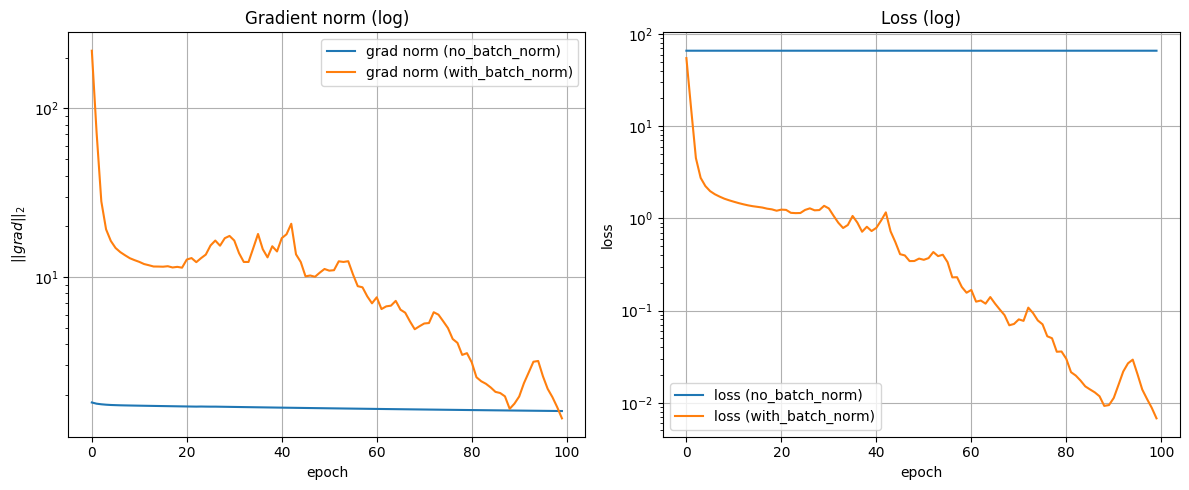

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gn_no_bn, label="grad norm (no_batch_norm)")
plt.plot(gn_with_bn, label="grad norm (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("$||grad||_2$")
plt.title("Gradient norm (log)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(loss_no_bn, label="loss (no_batch_norm)")
plt.plot(loss_with_bn, label="loss (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss (log)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Тут вы можете заметить классический пример затухающего градиента (vanishing gradients)

#### Левый график

График без нормы – горизонтальный и очень низкий на всём протяжении – градиенты крошечные → шаги оптимизатора микроскопические → сеть фактически не учится.

График с нормой стартует с больших значений (десятки–сотни), затем быстро спадает и колеблется в разумном диапазоне, постепенно уменьшаясь. Это здоровая картина: градиенты достаточно большие, чтобы двигать веса, и по мере приближения к минимуму становятся меньше.

#### Правый график

График без нормы – плато на высоком уровне – подтверждение, что без BN модель застряла и градиенты затухли.

График с нормой падает на несколько порядков (до 1e-2) с небольшими «волнами» – обучение идёт, лосс снижается.

### Взрыв градиента

Взрыв градиента – это когда производные растут неконтролируемо, шаги оптимизатора огромные, лосс скачет, появляются NaN/Inf.

С чем связано: слишком большой learning rate, плохая инициализация, очень глубокие сети/RNN, отсутствие нормализации.

Контрмеры: уменьшить LR, gradient clipping, **нормализации!**, корректная инициализация, residual-связи, weight decay.

In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

batch_size = 4096
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class DeepMLP(nn.Module):
    def __init__(self, in_dim=28 * 28, hidden=512, depth=12, use_bn=False):
        super().__init__()
        layers = []
        layers += [nn.Linear(in_dim, hidden)]
        if use_bn:
            layers += [nn.BatchNorm1d(hidden)]
        layers += [nn.Tanh()]  # tanh специально, чтобы без BN было тяжелее

        for _ in range(depth - 2):
            layers += [nn.Linear(hidden, hidden)]
            if use_bn:
                layers += [nn.BatchNorm1d(hidden)]
            layers += [nn.Tanh()]

        layers += [nn.Linear(hidden, 10)]  # logits для CrossEntropy
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


def grad_norm(model):
    total_sq = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total_sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(total_sq) if total_sq > 0 else 0.0


def evaluate(model, test_loader, loss_fn=nn.CrossEntropyLoss()):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += loss_fn(logits, y).item() * x.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return loss_sum / total, correct / total

In [ ]:
def train_model(
    model,
    optimizer,
    train_loader,
    test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=100,
    label="no_bn",
    plot_every_epochs=10,  # как часто перерисовывать графики
):
    model.to(device)
    gns, losses = [], []
    global_step = 0
    early_stop = False

    pbar = tqdm(range(epochs), desc=f"[{label}] training", unit="epoch")
    for epoch in pbar:
        model.train()
        for batch_idx, (x_train, y_train) in enumerate(train_loader):
            x_train, y_train = x_train.to(device), y_train.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_train)
            loss = loss_fn(logits, y_train)
            loss.backward()

            # норма градиента
            total_sq = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_sq += p.grad.detach().pow(2).sum().item()
            gn = math.sqrt(total_sq) if total_sq > 0 else 0.0

            gns.append(gn)
            losses.append(loss.item())

            # ранний стоп при NaN/Inf
            if not (math.isfinite(gn) and math.isfinite(loss.item())):
                print(
                    f"[{label}] epoch {epoch+1}, batch {batch_idx+1}: "
                    f"grad_norm={gn}, loss={loss.item()} → остановка (взрыв)."
                )
                early_stop = True
                break

            optimizer.step()
            global_step += 1

            # обновляем прогресс-бар (показываем последние значения)
            pbar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{gn:.2e}")

        # тротлим отрисовку: раз в N эпох или при ранней остановке
        if ((epoch + 1) % plot_every_epochs == 0) or early_stop:
            clear_output(wait=True)
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(gns, "-o", markersize=2)
            axes[0].set_title("grad_norm")
            axes[0].set_xlabel("step")
            axes[0].set_ylabel("||grad||₂")
            axes[1].plot(losses, "-o", markersize=2)
            axes[1].set_title("loss")
            axes[1].set_xlabel("step")
            axes[1].set_ylabel("loss")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

        if early_stop:
            print(
                f"[{label}] early stop at epoch {epoch+1}, global_step {global_step}."
            )
            break

    test_loss, test_acc = evaluate(model, test_loader)
    print(f"[{label}] TEST  loss={test_loss:.4f}, acc={test_acc:.4f}")
    return gns, losses

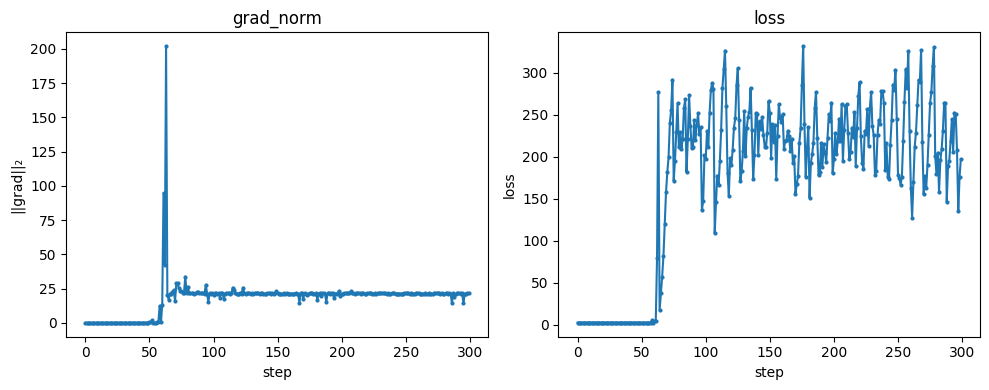

[NO_BN] training: 100%|██████████| 20/20 [02:17<00:00,  6.87s/epoch, grad_norm=2.16e+01, loss=196.9127]


[NO_BN] TEST  loss=236.3155, acc=0.1009


In [ ]:
depth = 12
lr = 1.0
epochs = 20

model_no_batch_norm = DeepMLP(depth=depth, use_bn=False)
model_no_batch_norm = model_no_batch_norm.to(device)
optimizer_no_batch_norm = torch.optim.SGD(model_no_batch_norm.parameters(), lr=lr)

gn_no_bn, loss_no_bn = train_model(
    model_no_batch_norm,
    optimizer_no_batch_norm,
    train_loader,
    test_loader,
    epochs=epochs,
    label="NO_BN",
)

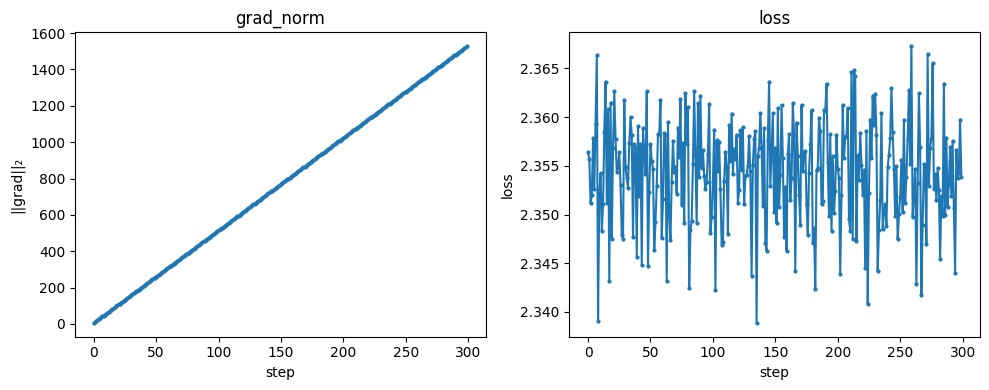

[WITH_BN] training: 100%|██████████| 20/20 [02:28<00:00,  7.42s/epoch, grad_norm=1.53e+03, loss=2.3539]


[WITH_BN] TEST  loss=2.3625, acc=0.0914


In [ ]:
model_with_batch_norm = DeepMLP(depth=depth, use_bn=True)
model_with_batch_norm = model_with_batch_norm.to(device)
optimizer_with_batch_norm = torch.optim.SGD(model_no_batch_norm.parameters(), lr=lr)

gn_with_bn, loss_with_bn = train_model(
    model_with_batch_norm,
    optimizer_with_batch_norm,
    train_loader,
    test_loader,
    epochs=epochs,
    label="WITH_BN",
)

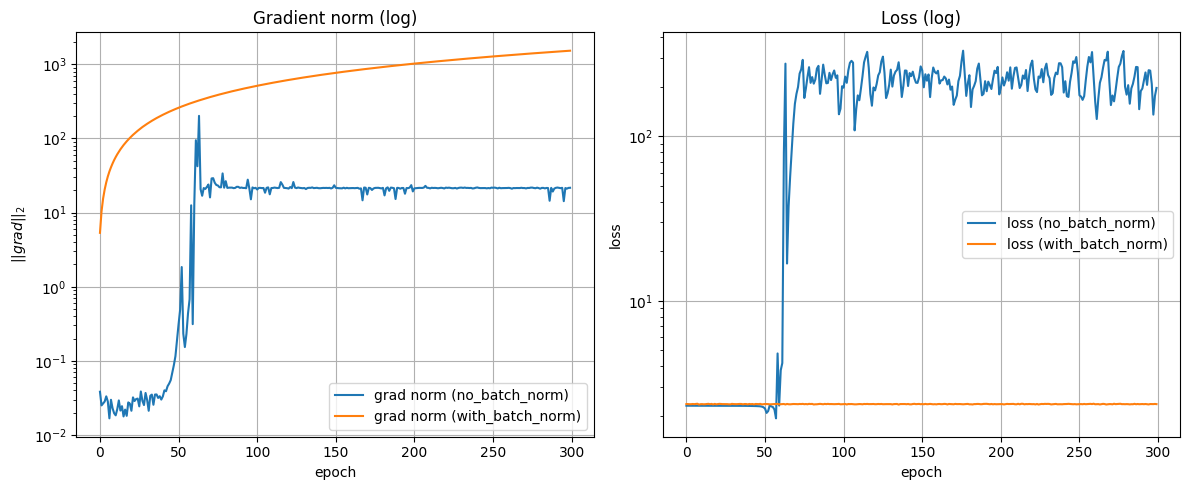

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(gn_no_bn, label="grad norm (no_batch_norm)")
plt.plot(gn_with_bn, label="grad norm (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("$||grad||_2$")
plt.title("Gradient norm (log)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(loss_no_bn, label="loss (no_batch_norm)")
plt.plot(loss_with_bn, label="loss (with_batch_norm)")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss (log)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Левый график:

Без BatchNorm – Сначала градиенты крошечные (почти тормозим), потом около ~55-й эпохи — резкий взрыв на несколько порядков: шаги становятся гигантскими, начинается разнос

C BatchNorm – Растёт плавно и остаётся в разумных пределах — без резких скачков и бесконечностей. Это признак стабильного обратного распространения.

##### Правый график:

Без нормализации глубокая сеть с большим LR быстро уходит в область, где активации/градиенты раздуваются → шаги оптимизатора становятся неадекватными → лосс улетает

BatchNorm выравнивает масштаб активаций в каждом слое, стабилизируя backprop. Поэтому даже при завышенном LR и большой глубине обучение остаётся управляемым